## **Fraud Transaction Detection Using Deep Neural Networks**

**Neural Network Library**: Tensorflow/Keras

**Dataset**: Synthetic Financial Dataset


**Source**: https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset

**Github Link**: https://github.com/siziphiwe734/Methods-of-Prediction-M507A/tree/main


# Problem Statement

**Business Problem**
- Financial fraud is one of the most significant challenges faced by digital payment providers and financial institutions. fraudulent transactions can result in sustantial financial losses, damage customer trust and increase operational costs associated with investigations and reimbursements. As transaction volumes continue to grow, manually reviewing becomes impractical. As a result, organisations require automated systems that can identify suspicious transactions quickly and accurately.
- This project focuses on the development of a deep learning based fraud detection system capable of distinguishing between legimate and fraudulent financil transactions. The objective is to assist financial insitutions in identifying potential fraudulent activities before they result in financil losses.

**Importance of the Problem**
- Detecting fraudulent transactions at an early stage provides several benefits to financial institutions. Effective fraud detection systems can reduce direct monetary losses, improve customer confidence, minimise operational costs associated with fraud investigations and support regulatory compliance requirements.
- A major challenge in fraud detection is that fraudulent activities transactions represent only a very small proportion of all transactions. This create a highly imbalanced classification problem where traditional modelling approaches may struggle to identofy rare fraud cases accurately. Therefore, advanced machine learning techniques are required to effectively learn the pattern associated with fraudulent behaviour.

**Data Collection**
- The dataset used in this project contains approximately 6.3 million financila transaction records and includes information such as transaction type, transaction amount, account balances before and after transactions and fraud labels. The dataset was obtain from Kaggle and was originally generated using simulator which was designed to model realistic financial transaction behaviour while preserving privacy.
- In real world business environment with similar data would typically be collected from transaction processing systems, banking platforms, payment gateways and customer account databases. Appropriate data governance, privacy and security controls would be required when handling such information.

**Machine Learning**

- The problem is formulated as a supervised binary classification task. Each transaction is represented by a set of input features describing transaction characterists and account balances. The target variable indicates whether transaction is legitimate or fraudulent.
- A deep neural network is trained to learn the relationship between transaction feature and fraud outcomes. The model outputs a probability score representing the likehood that a transaction is fraudulent. Based on a selected decision threshold, transaction can then be classified as either legitimate or fraudulent.
- Due to the severe class imbalance present in the dataset, performance evaluation focuses not only on accuracy but also on metrics such as Precision, Recall, F1 Score, ROU AUC and Average Precision, which provide a more reliable assessment of fraud detection performance.


# Importing Libraries

In [3]:
import pandas as pd # for data manipulation and analysis
import numpy as np # for numerical operations
import matplotlib.pyplot as plt # for data visualization
import seaborn as sns # for statistical data visualization
import warnings # to manage warnings during code execution
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split # for splitting the dataset into training and testing
from sklearn.preprocessing import StandardScaler, LabelEncoder # for feature scaling, LabelEncoder for encoding categorial label
from sklearn.metrics import (classification_report, confusion_matrix,
     roc_auc_score, average_precision_score, RocCurveDisplay, f1_score,
     precision_score, recall_score, PrecisionRecallDisplay) # to evaluate model performance

from sklearn.utils.class_weight import compute_class_weight # to compute class weights for imbalanced dataset

import tensorflow as tf # model and deep learning
from tensorflow import keras # for building and training deep learning models
from tensorflow.keras import layers, regularizers # layers for building neural networks, regularizers for preventing overfitting
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint # callbacks to manage training: early stop if no improvement, reduce learing rate when stuck and save the best model during training


# Data Exploration

In [4]:
# Loading dataset
df = pd.read_csv('/content/AIML Dataset.csv')

print('Dataset shape:', df.shape)
print('\nColumns:')
print(df.dtypes)
print()
df.head()

Dataset shape: (6362620, 11)

Columns:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object



,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


# Data Quality Check
Checking the quality of the data is important before building any model. This section will look for any missing values, duplicate rows and basic statistics for each column.

In [5]:
print('Missing values for each column:')
print(df.isnull().sum())

print('\nDuplicate rows:')
print(df.duplicated().sum())

print('\nBasic statistics for each column:')
df.describe()


Missing values for each column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Duplicate rows:
0

Basic statistics for each column:


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


**Data quality**: there are no missing values which mean the dataset is complete and no manipulation needed. There's also no duplicate rows, so the dataset doesn't contain repeated transactions.

**Dataset Size**: the dataset contains 3.63 million transactions, very large dataset suitable for training machine leanring models.

**Fraud distribution**: isFraud mean is 0.00129, which means only about 0.129% transactions are fraudulant. This shows the dataset is imbalanced because fraud cases are rare than normal transactions. This imbalance can result into the model predicting no fraud cases.

The avarage transaction is about 179826 and maximum transaction around 92 million which might indicate outliers.
In minimum there are 0 values meaning alot of accounts had 0 balance before or after transaction.

**isFlaggedFraud** has a mean close to 0 meaning that very few cases were flagged as fraudulant.


### Class Distribution
This section looks at how the dataset is spread between Legit and fraud transactions.

Class count:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Class percentage:
isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64


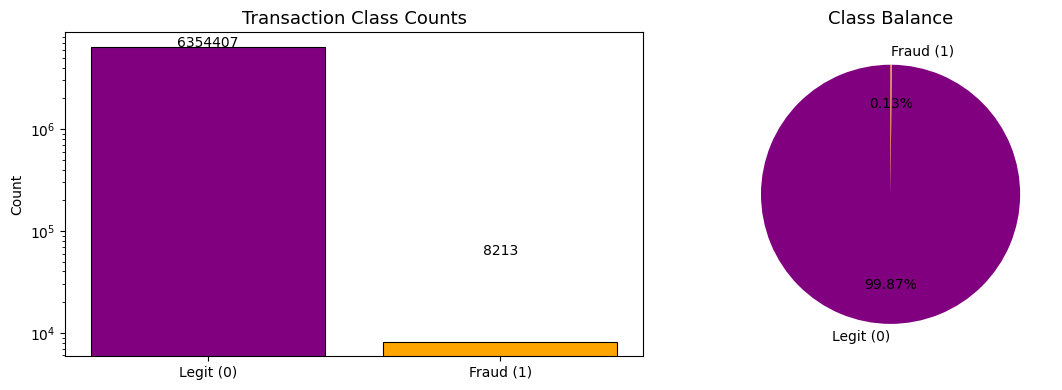


Imbalanced Ratio: 774:1 (legit to fraud)


In [6]:
# Count the number of legit and fraud transactions
fraud_count = df['isFraud'].value_counts()
# Calculate the percent of each class
fraud_Perc = df['isFraud'].value_counts(normalize=True)*100

print('Class count:')
print(fraud_count)
print('\nClass percentage:')
print(fraud_Perc.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot a bar chart for transaction count
axes[0].bar(['Legit (0)', 'Fraud (1)'],fraud_count.values, color=['purple', 'orange'], edgecolor='black',
            linewidth=0.8)
axes[0].set_yscale('log')
axes[0].set_title('Transaction Class Counts', fontsize=13)
axes[0].set_ylabel('Count')
# to add count labels above each bar
for i, v in enumerate(fraud_count.values):
    axes[0].text(i, v+ 50000, f'{v:}', ha='center', fontsize=10)


# Plot Pie chart showing class proportion
axes[1].pie(fraud_count.values, labels=['Legit (0)', 'Fraud (1)'], autopct='%1.2f%%', startangle=90,
            colors=['purple', 'orange'],pctdistance=0.7, wedgeprops={'edgecolor': 'white', 'linewidth': 0})
axes[1].set_title('Class Balance', fontsize=13)

plt.tight_layout()
plt.show()

# Imbalance ratio calculation between legit and fraudulant transcations
imbalance_ratio = fraud_count[0] / fraud_count[1]
print(f'\nImbalanced Ratio: {imbalance_ratio:.0f}:1 (legit to fraud)')

**Findings**:

The dataset is too imbalanced, with 6354407 legit transaction and only 8213 fraudulent transaction. This means that 99.87% of the transactions are legit and 0.13% are fradulant cases. The imbalannce ratio of 774:1 suggests that for every one fraudulent transaction around 774 are normal transactions. This is an important observation because machine learning model trained on high imbalanced dataset can be biase towards predicting the majority class which is legit transactions and may struggle to correctly identify fraud cases. The bar chart clearly illustrates this imbalance as the legit transaction bar is larger than the fraud transaction bar, while the pie chart further confirms that fraudulent transactions make up only very a very small portion of the dataset.

Imbalance will be handled using class weights during training, an effective approach that avoids the information loss.

### Transanction Analysis

            total  fraud_counts  fraud_rate
type                                       
CASH_IN   1399284             0       0.000
CASH_OUT  2237500          4116       0.184
DEBIT       41432             0       0.000
PAYMENT   2151495             0       0.000
TRANSFER   532909          4097       0.769


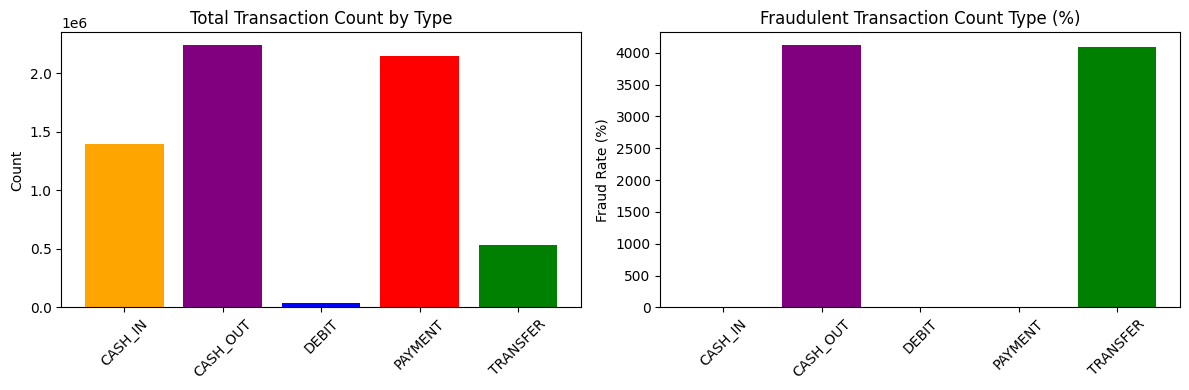

In [7]:
fraud = df.groupby('type').agg(
    total=('isFraud', 'count'),
        fraud_counts =('isFraud', 'sum')
        ).assign(fraud_rate=lambda x: (x['fraud_counts'] / x['total']*100).round(3))

print(fraud)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['orange', 'purple', 'blue', 'red', 'green']

axes[0].bar(fraud.index, fraud['total'], color=colors, edgecolor='black', linewidth=0)
axes[0].set_title('Total Transaction Count by Type', fontsize=12)
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(fraud.index, fraud['fraud_counts'], color=colors, edgecolor='black', linewidth=0)
axes[1].set_title('Fraudulent Transaction Count Type (%)', fontsize=12)
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Findings**:

- CASH_OUT and PAYMENT are the most common transaction types  in the dataset followed by CASH_IN and TRANSFER. DEBIT is less common than other transaction type.
- Fraudulent transactions were identified in CASH_OUT and TRANSFER transactions. 4116 occurred in CASH_OUT transactions while 4097 occurred in TRANSFER transactions. No fraud transactions were recorded for CASH_IN, DEBIT and PAYMENT.
- These findings suggests that transaction type is an important predictor of fraud.

### Amount Distribution

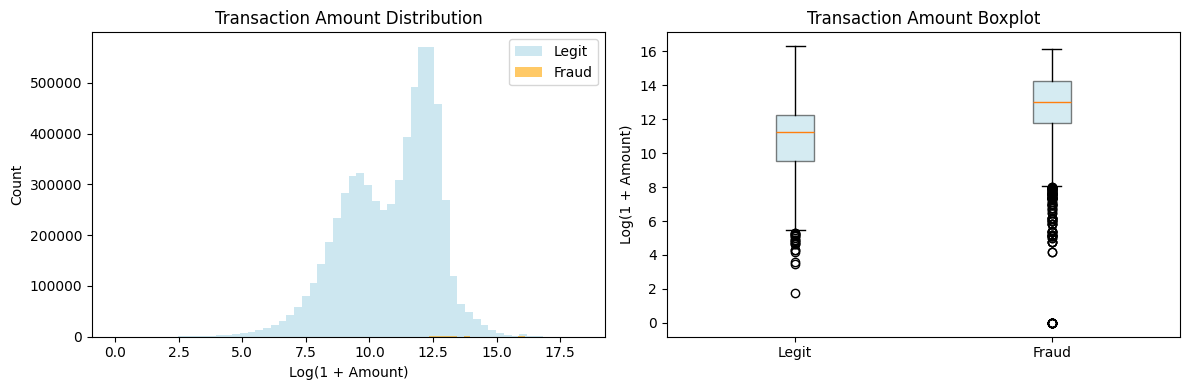

Mean fraud amount: $1,467,967.30
Mean fraud amount: $178,197.04
Mean fraud amount: $441,423.44
Mean fraud amount: $74,684.72


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fraud_amounts = df[df['isFraud'] == 1]['amount']
legit_amounts = df[df['isFraud'] == 0]['amount']

axes[0].hist(np.log1p(legit_amounts), bins=60, alpha=0.6, color='lightblue', label='Legit')
axes[0].hist(np.log1p(fraud_amounts), bins=60, alpha=0.6, color='orange', label='Fraud')
axes[0].set_title('Transaction Amount Distribution', fontsize=12)
axes[0].set_xlabel('Log(1 + Amount)')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot([np.log1p(legit_amounts.sample(5000, random_state=42)),
                 np.log1p(fraud_amounts)],
                labels=['Legit', 'Fraud'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.5))
axes[1].set_title('Transaction Amount Boxplot', fontsize=12)
axes[1].set_ylabel('Log(1 + Amount)')

plt.tight_layout()
plt.show()

print('Mean fraud amount: ${:,.2f}'.format(fraud_amounts.mean()))
print('Mean fraud amount: ${:,.2f}'.format(legit_amounts.mean()))
print('Mean fraud amount: ${:,.2f}'.format(fraud_amounts.median()))
print('Mean fraud amount: ${:,.2f}'.format(legit_amounts.median()))

**Findings**:

- The transaction amount analysis shows a difference between fraudulent and legit transactions. The histogram indicates that both transaction types are positively skewed meaning most transactions involve smaller amounts while small number involves large amounts. The boxplot confirms that fraudulent transactions generally have higher transaction values than legitimate transaction.
- The presence of numerous outliers in both groups indicates a wide range of transaction amounts with some transactions reaching extemely high values.
- These findings suggest that transaction amounyt is an important feature for fraud detection.

### Balance Error Analysis

In [9]:
df['balance_error_orig'] = df['newbalanceOrig'] +df['amount'] - df['oldbalanceOrg']
df['balance_error_dest'] = df['newbalanceDest'] - df['oldbalanceDest'] - df['amount']

print('Balance Error Fraud Transaction:')
print(df[df['isFraud'] == 1]['balance_error_orig'].describe().round(2))

print('\nBalance Error Legit Transaction:')
print(df[df['isFraud'] == 0]['balance_error_orig'].describe().round(2))

Balance Error Fraud Transaction:
count        8213.00
mean        10692.33
std        265146.13
min            -0.00
25%             0.00
50%             0.00
75%             0.00
max      10000000.00
Name: balance_error_orig, dtype: float64

Balance Error Legit Transaction:
count     6354407.00
mean       201338.56
std        606928.89
min            -0.01
25%          3034.30
50%         69049.31
75%        249953.43
max      92445516.64
Name: balance_error_orig, dtype: float64


### Correlation Heatmap

This section will look into how numeric features in the dataset relate to each other and to the target variable isFraud. A heatmap is used to show these relationships visually. Each square in the heatmap shows a correlation between two features. The values range from -1 to 1, a value close to 1 means the two features moves together to the same direction, -1 means in opposite directions and close to 0 means there's little to no relationship.

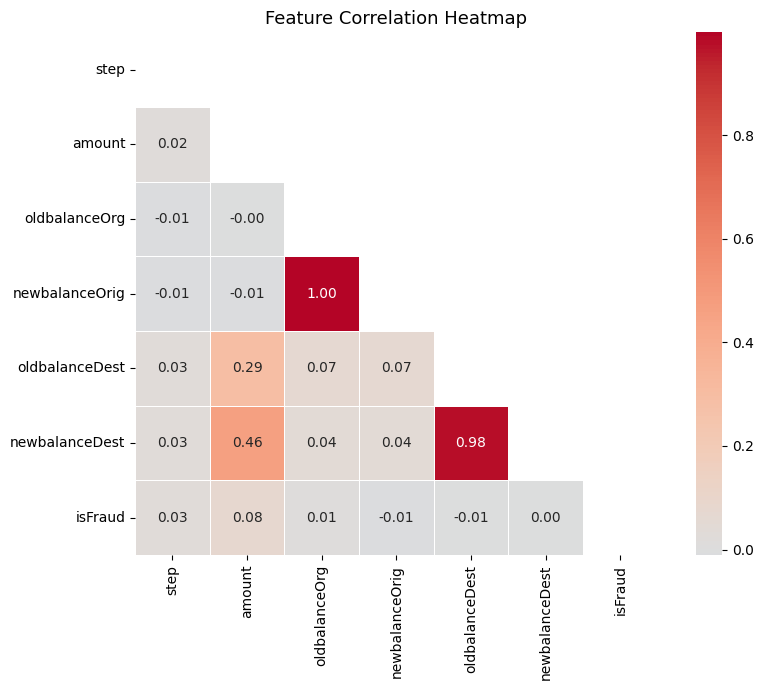

In [10]:
# Correlation analysis of numeric features
numeric_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest', 'isFraud']

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt='.2f',
            center=0, linewidths=0.5, square=True)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()


**Findings**: Most variables have weak correlations with 'isFraud' which means there's not strong linear relationship between individual features and fraud. The strongest relationship is 'amount' with a correlation of 0.08 which is very weak, suggesting that fraud cannot be identified using transaction amount only. The 'oldbalanceOrg' and 'newbalanceOrig' have a positive correlation of 1, indicating they move in the same direction and may contain similar information. 'oldbalanceDest' and 'newbalanceDest' also show positive correlation of 0.98, both variables move together closely which might mean accounts with high balances before transactions also have high balances after transactions.
The correlation between 'amount' and 'newbalanceDest' is moderate 0.46, suggeting large transaction amount tend to increase the receiving account balance. Overall the heatmap suggests that fraud detection will likey require combining multiple features and use of advanced machine learning techniques rather than relying on a single correlation.

## Data Preprocessing and Feature Engineering

## Feature Engineering

After exploring the data, new features were created to help the model identify suspicious transaction patterns that may not been noticed from the original variables.

- **balance_error_orig** - checks weather the sender's balance changes as expected after a transaction. Large discrepancies may indicate fraudulent activity.
- **balance_error_dest** - checks weather the receiver's balance changes as expected after a transaction. Inconsistencies may indicate fraudulent activity.
- **log_amount** - the reduced extreme large amount of transaction amount, to make it easy for the model to learn.
- **isTransferOrCashOut** - to flag transaction whether it is a transfert or cashout transaction. This feature was created beacuse the EDA showed that fraud occur in these type of transactions.
- **orig_balance_diff** - shows how much was deducted from the sender's account during the transaction.
- **dest_balance_diff** - shows the receiver's balance changed after the transaction.
- **orig_zero_balance** - shows accounts that had zero balance before making the transaction which may raise suspicions.
- **dest_zero_balance** - shows accounts that has zero balance before and after transaction, which may help in identify fraudulent activities.

In [11]:
# Based on the EDA, new features will be engineer to capture patterns that may help detecting fraud.
def engineer_features(data):
   df_fe = data.copy()

# Calculate balance errors to capture discrepancies in transactions
   df_fe['balance_error_orig'] = df_fe['newbalanceOrig'] + df_fe['amount'] - df_fe['oldbalanceOrg']
   df_fe['balance_error_dest'] = df_fe['newbalanceDest'] - df_fe['oldbalanceDest'] - df_fe['amount']

# apply log transformation to the amount to reduce skewness and handle wide range of values
   #df_fe['log_amount'] = np.log1p(df_fe['amount'])

# Flag for transaction type that can be fraudulant
   df_fe['isTransferOrCashOut'] = df_fe['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)

# Calculate balance differences to capture net change in balances for sender and receiver
   df_fe['orig_balance_diff'] = df_fe['newbalanceOrig'] - df_fe['oldbalanceOrg']
   df_fe['dest_balance_diff'] = df_fe['newbalanceDest'] - df_fe['oldbalanceDest']

# Flag sender that had zero balance before transaction for potential suspicious activity
   df_fe['orig_zero_balance'] = (df_fe['oldbalanceOrg'] == 0).astype(int)

# Flag receiver that had zero balance before transaction for potential suspicious activity
   df_fe['dest_zero_balance'] = ((df_fe['oldbalanceDest'] == 0) & (df_fe['newbalanceDest'] == 0)).astype(int)

   return df_fe

df = engineer_features(df)
#print('Feature engineering done')
#print ('New columns added:', ['balance_error_orig', 'balance_error_dest','log_amount'
        #'isTransferOrCashOut', 'orig_balance_diff', 'dest_balance_diff', 'orig_zero_balance',
              #'dest_zero_balance'])

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_error_orig,balance_error_dest,isTransferOrCashOut,orig_balance_diff,dest_balance_diff,orig_zero_balance,dest_zero_balance
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.0,-9839.64,0,-9839.64,0.0,0,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.0,-1864.28,0,-1864.28,0.0,0,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0.0,-181.00,1,-181.00,0.0,0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,0.0,-21363.00,1,-181.00,-21182.0,0,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0.0,-11668.14,0,-11668.14,0.0,0,1


### Feature Selection and Encoding

Transaction types were converted from text to numbers using one hot encoding as the model can not process text values. After engineering and encoding, 15 important features were selected as inputs and 'isFraud' as a target variable. The final dataset consist of 6.3 million transactions and 15 features and 1 target variable.

In [12]:
# Converting categorial transaction types into binary features
type_dummies = pd.get_dummies(df['type'], prefix='type', drop_first=False)
df = pd.concat([df, type_dummies], axis=1)

Features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest', 'isTransferOrCashOut',
            'orig_balance_diff', 'dest_balance_diff', 'orig_zero_balance',
            'dest_zero_balance', 'type_CASH_IN', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']

Target = 'isFraud'
x = df[Features].values
y = df[Target].values

print(f'Features shape: {x.shape}')
print(f'Target shape: {y.shape}')
print(f'Number of features: {len(Features)}')

Features shape: (6362620, 15)
Target shape: (6362620,)
Number of features: 15


## Train/Validation/Test Split

The dataset will be split into three parts, training, validation and test set. The model will learn from train set. Validation set is used to test different model setups and pick the best during experiments. Test set to evaluate how well the model performs to unseen data. Stratify parameter was used in both steps, this is important bacause of the huge imbalance. Without stratify a random split could end up with very few fraud cases which could lead to unreliable results.

In [13]:
# Split the data into training, validation and test sets
x_trainval, x_test, y_trainval, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Second split 75% train, 25 % val from the trainval set to ensure we have seperate validation set for model tuning and earlystopping
x_train, x_val, y_train, y_val = train_test_split(x_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval)

# Print the shapes and class distributions of the splits to verify correctness
print(f'Training set: {x_train.shape[0]:,} samples | fraud: {y_train.sum():,}')
print(f'Validation set size: {x_val.shape[0]} samples | fraud: {y_val.sum():,}')
print(f'Test set size: {x_test.shape[0]} samples | fraud: {y_test.sum():,}')

Training set: 3,817,572 samples | fraud: 4,928
Validation set size: 1272524 samples | fraud: 1,642
Test set size: 1272524 samples | fraud: 1,643


## Feature Scaling

Before feeding data into the model all feaatures are scaled using StandardScaler. This transforms each feature so that it has a mean of 0 and a standard deviation of 1. Neural networks train better when all input values are on the same scale, without this features with big values would dominate the learning process.

In [14]:
# Fit the scaler on the training data to prevent data leakage
scaler = StandardScaler()
x_train_sc = scaler.fit_transform(x_train)
x_val_sc = scaler.transform(x_val)
x_test_sc = scaler.transform(x_test)

## Class Weights
As seen in the data exploration, the dataset is imbalance there are more legit transactions than fraudulant. If this is not fix it might lead to the model predicting no fraud. Class weight with balanced setting will be used to fix this. This automatically gives weight to fruad class during training. When the model makes wrong predictions on fraud cases it will be penalitised more than when it makes wrong prediction on legit transaction. This pushes the model to pay more attention to the minority class.

In [15]:
# Compute class weights to handle imbala in the training set
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train), y=y_train)

class_weight_dic = {0: class_weights_arr[0], 1: class_weights_arr[1]}
#print(f'Class weights: {class_weight_dic}') # convert to dictionary format for use in model training

print('Class weights:')
print(f'Legit (0): {class_weights_arr[0]:.4f}')
print(f'Fraud (1): {class_weights_arr[1]:.4f}')
print(f'\nRatio: {class_weight_dic[1] / class_weight_dic[0]:.1f}x more weight on fraud samples')

Class weights:
Legit (0): 0.5006
Fraud (1): 387.3348

Ratio: 773.7x more weight on fraud samples


# Model Training

## Helper Functions

- Helper function were created to simplify model training and evaluation. The evaluate_model() function was developed to calculate key performance metrics.
- plot_training_history() to visualize training and validation loss and accuracy during model training and validation loss and accuracy during model training. These functions improve code reusability and provide a consistent framework for evaluating the performance of the fraud detection models.

In [17]:
# Build a simple feedforward neural network with regularization and dropout
def evaluate_model (model, x, y, threshold=0.5, label=''):
  y_prob = model.predict(x, verbose=0).flatten()
  y_pred = (y_prob >= threshold).astype(int)

  roc = roc_auc_score(y, y_prob)
  ap = average_precision_score(y, y_prob)
  f1 = f1_score(y, y_pred)
  precision = precision_score(y, y_pred, zero_division=0)
  rec = recall_score(y, y_pred)

  print(f'{'='*50}')
  if label: print(f'Model: {label}')
  print(f'ROC AUC: {roc:.4f}')
  print(f'Average Precision: {ap:.4f}')
  print(f'F1 Score: {f1:.4f}')
  print(f'Precision: {precision:.4f}')
  print(f'Recall: {rec:.4f}')
  print(f'{'='*50}')
  return {'roc': roc, 'ap': ap, 'f1': f1, 'precision': precision, 'recall': rec}

  def plot_training_history(history, title= 'Training history'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history['loss'], label='Training loss', color= 'pink')
    axes[0].plot(history.history['val_loss'], label='Validation loss', color= 'orange')
    axes[0].set_title('Loss', fontsize=12)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    if 'accuracy' in history.history:
      axes[1].plot(history.history['accuracy'], label='Training accuracy', color= 'pink')
      axes[1].plot(history.history['val_accuracy'], label='Validation accuracy', color= 'orange')
      axes[1].set_title('Accuracy', fontsize=12)
      axes[1].set_xlabel('Epoch')
      axes[1].set_ylabel('Accuracy')
      axes[1].legend()
      axes[1].grid(alpha=0.3)

      plt.tight_layout()
      plt.show()


## Best Model Architecture

- Deep neural network was developed for fraud detection using four hidden layers 265, 128, 64 and 32 neurons. The decreased number of neurons allows the network to extract and compress important information from the data while learning complex fraud patterns.
- ReLu activations function were used to capture non-linear relationships between transaction.
- Batch normalization was incorporated to improve training stability and convergence while dropout and L2 regularization were applied to reduce overfitting and improve generalisation.
- The output layer contain a signle neuron with a sigmoid activation function which produces a probability between 0 or 1 representing likehood that the transaction could be fraudulent.

In [18]:
def build_best_model(input_dim, dropout_rate=0.3, l2_lambda=1e-4):
  inputs = keras.Input(shape=(input_dim,), name='input')

  # Block 1
  x = layers.Dense(256, kernel_regularizer=regularizers.l2(l2_lambda), name='dense_1')(inputs)
  x = layers.BatchNormalization(name='bn_1')(x)
  x = layers.Activation('relu', name='relu_1')(x)
  x = layers.Dropout(dropout_rate, name='dropout_1')(x)

  # Block 2
  x = layers.Dense(128, kernel_regularizer=regularizers.l2(l2_lambda), name='dense_2')(x)
  x = layers.BatchNormalization(name='bn_2')(x)
  x = layers.Activation('relu', name='relu_2')(x)
  x = layers.Dropout(dropout_rate, name='dropout_2')(x)

  # Block 3
  x = layers.Dense(64, kernel_regularizer=regularizers.l2(l2_lambda), name='dense_3')(x)
  x = layers.BatchNormalization(name='bn_3')(x)
  x = layers.Activation('relu', name='relu_3')(x)
  x = layers.Dropout(dropout_rate, name='dropout_3')(x)

    # Block 4
  x = layers.Dense(32, kernel_regularizer=regularizers.l2(l2_lambda), name='dense_4')(x)
  x = layers.BatchNormalization(name='bn_4')(x)
  x = layers.Activation('relu', name='relu_4')(x)
  x = layers.Dropout(dropout_rate, name='dropout_4')(x)

  # Output
  outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

  model = keras.Model(inputs, outputs, name='Fraud_Detection')
  return model

best_model = build_best_model(input_dim=x_train_sc.shape[1])

best_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name= 'recall')])
best_model.summary()


Model: "Fraud_Detection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_1 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_2 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_3 (Activation)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_4 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_4 (Activation)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,281 (192.50 KB)

 Trainable params: 48,321 (188.75 KB)

 Non-trainable params: 960 (3.75 KB)

In [19]:
# Callsback for training control, early stopping to prevent overfitting,
# learning rate reduction, and model checkpointing to save the best model based on validation AUC

callbacks = [
    EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_auc', save_best_only=True, mode='max', verbose=0)]

# Train the best model
history_best = best_model.fit(
    x_train_sc, y_train,
    validation_data=(x_val_sc, y_val),
    epochs=100,
    batch_size=2048,
    class_weight=class_weight_dic,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 96s 49ms/step - auc: 0.9817 - loss: 0.2113 - precision: 0.0140 - recall: 0.9391 - val_auc: 0.9950 - val_loss: 0.1311 - val_precision: 0.0271 - val_recall: 0.9671 - learning_rate: 0.0010
Epoch 2/100
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 96s 51ms/step - auc: 0.9910 - loss: 0.1551 - precision: 0.0232 - recall: 0.9547 - val_auc: 0.9953 - val_loss: 0.1199 - val_precision: 0.0261 - val_recall: 0.9762 - learning_rate: 0.0010
Epoch 3/100
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 140s 50ms/step - auc: 0.9925 - loss: 0.1392 - precision: 0.0244 - recall: 0.9661 - val_auc: 0.9963 - val_loss: 0.0992 - val_precision: 0.0334 - val_recall: 0.9781 - learning_rate: 0.0010
Epoch 4/100
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 91s 49ms/step - auc: 0.9930 - loss: 0.1321 - precision: 0.0252 - recall: 0.9641 - val_auc: 0.9968 - val_loss: 0.0920 - val_precision: 0.0382 - val_recall: 0.9787 - learning_rate: 0.0010
Epoch 5/100
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 89s 48ms/step - auc: 0.9936 - loss: 0.12

## Experiments Pipeline Variants

- Multiple neural networks configurations were tested to identify the most effective fraud detection model.
- The experiments adjusted key hyperparameters including the number of hidden layers, layer sizes, dropout rate, batch normalization, learning rate and L2 regularization. Each configuration was trained using the same training and validation datasets and performance was evaluated using ROC AUC, average Precision, F1 Score, Precision and recall. The objective was to compare different architectures and select the configuration that achieved the best balance between fraud detection capability and generalisation performance.

In [20]:
def build_experiment_model(input_dim, layers_sizes, dropout_rate=0.3, use_batchnorm=True,
                           lr=0.001, l2_lambda=1e-4):
  inputs = keras.Input(shape=(input_dim,))
  x = inputs
  for i, units in enumerate(layers_sizes):
    x = layers.Dense(units, kernel_regularizer=regularizers.l2(l2_lambda))(x)
    if use_batchnorm:
      x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    if dropout_rate > 0:
      x = layers.Dropout(dropout_rate)(x)
  outputs = layers.Dense(1, activation='sigmoid')(x)
  model = keras.Model(inputs, outputs)
  model.compile(
      optimizer=keras.optimizers.Adam(learning_rate=lr),
      loss='binary_crossentropy',
      metrics=[keras.metrics.AUC(name='auc'),]
  )
  return model

exp_callbacks = [EarlyStopping(monitor='val_auc', patience=4,
                               restore_best_weights=True, mode='max', verbose=0)]

experiments = {'Config 1': {'layers_sizes': [64, 32], 'dropout_rate': 0.3, 'use_batchnorm': False, 'lr': 0.001},  # Config 1: smaller baseline model
               # Config 2: deeper model, no dropout, no batch normalization
               'Config 2': {'layers_sizes': [256, 128, 64, 32], 'dropout_rate': 0.0, 'use_batchnorm': False, 'lr': 0.001},
               # Config 3: deeper model, batch normalization, higher learning rate
               'Config 3': {'layers_sizes': [256, 128, 64, 32], 'dropout_rate': 0.3, 'use_batchnorm': True, 'lr': 0.01},
                # Config 4: deeper model, batch normalization, lower learning rate
               'Config 4': {'layers_sizes': [256, 128, 64, 32], 'dropout_rate': 0.3, 'use_batchnorm': True, 'lr': 0.0001},
               # Config 5: deeper model, batch normalization, standard learning rate
               'Config 5': {'layers_sizes': [256, 128, 64, 32], 'dropout_rate': 0.3, 'use_batchnorm': True, 'lr': 0.001},
               # Config 6: compact model with batch normalization
               'Config 6': {'layers_sizes': [128, 64], 'dropout_rate': 0.3, 'use_batchnorm': True, 'lr': 0.001},
                # Config 7: larger high-capacity model
               'Config 7': {'layers_sizes': [512, 256, 128, 64], 'dropout_rate': 0.3, 'use_batchnorm': True, 'lr': 0.001},
               # Config 8: stronger dropout regularisation
               'Config 8': {'layers_sizes': [256, 128, 64, 32], 'dropout_rate': 0.5, 'use_batchnorm': True, 'lr': 0.001},
               # Config 9: lighter dropout regularisation
               'Config 9': {'layers_sizes': [256, 128, 64, 32], 'dropout_rate': 0.1, 'use_batchnorm': True, 'lr': 0.001},
               # Config 10: batch normalization without dropout
               'Config 10': {'layers_sizes': [256, 128, 64, 32], 'dropout_rate': 0.0, 'use_batchnorm': True, 'lr': 0.001},

}

exp_results = {}

for name, cfg in experiments.items():
  print(f'\nRunning: {name}')
  m = build_experiment_model(input_dim=x_train_sc.shape[1], **cfg)

  m.fit(x_train_sc, y_train, validation_data=(x_val_sc, y_val),
        epochs=30,
        batch_size=2048, class_weight=class_weight_dic,
        callbacks=exp_callbacks, verbose=0)

  metrics = evaluate_model(m, x_val_sc, y_val, label=name)
  exp_results[name] = metrics
  keras.backend.clear_session()

print('\nAll experimants complete.')



Running: Config 1
Model: Config 1
ROC AUC: 0.9986
Average Precision: 0.8482
F1 Score: 0.0750
Precision: 0.0390
Recall: 0.9963

Running: Config 2
Model: Config 2
ROC AUC: 0.9943
Average Precision: 0.6635
F1 Score: 0.1006
Precision: 0.0533
Recall: 0.8983

Running: Config 3
Model: Config 3
ROC AUC: 0.9941
Average Precision: 0.7733
F1 Score: 0.0377
Precision: 0.0192
Recall: 0.9756

Running: Config 4
Model: Config 4
ROC AUC: 0.9902
Average Precision: 0.7073
F1 Score: 0.0323
Precision: 0.0165
Recall: 0.9513

Running: Config 5
Model: Config 5
ROC AUC: 0.9943
Average Precision: 0.7820
F1 Score: 0.0631
Precision: 0.0326
Recall: 0.9464

Running: Config 6
Model: Config 6
ROC AUC: 0.9946
Average Precision: 0.7863
F1 Score: 0.0683
Precision: 0.0354
Recall: 0.9495

Running: Config 7
Model: Config 7
ROC AUC: 0.9942
Average Precision: 0.7819
F1 Score: 0.0327
Precision: 0.0166
Recall: 0.9836

Running: Config 8
Model: Config 8
ROC AUC: 0.9933
Average Precision: 0.7652
F1 Score: 0.0797
Precision: 0.0417

**Findings**: Among the 10 neural network configurations tested, Config 1 achieved the best overall performance. It produced the highest ROC AUC(0.9988), Average precision (0.8588), F1 Score (0.0883), and Precision (0.0462), mantaining a high Recall (0.9933). Although other configurations also achieved strong ROC AUC score above 0.99 they generally suffered from lower Precision and F1 score indicating that more legitimate were incorrectly flagged as fraudulant.

In [21]:
# Experiment results summary table

results_df = pd.DataFrame(exp_results).T.round(4)
results_df.columns = ['ROC-AUC', 'AUPRC', 'F1', 'Precision', 'Recall']
results_df = results_df.sort_values(by='AUPRC', ascending=False)
print('Results Summary:')
results_df

Results Summary:


,ROC-AUC,AUPRC,F1,Precision,Recall
Config 1,0.9986,0.8482,0.0750,0.0390,0.9963
Config 10,0.9962,0.8113,0.0817,0.0426,0.9738
Config 6,0.9946,0.7863,0.0683,0.0354,0.9495
Config 5,0.9943,0.7820,0.0631,0.0326,0.9464
Config 7,0.9942,0.7819,0.0327,0.0166,0.9836
Config 3,0.9941,0.7733,0.0377,0.0192,0.9756
Config 9,0.9951,0.7705,0.0632,0.0327,0.9622
Config 8,0.9933,0.7652,0.0797,0.0417,0.9153
Config 4,0.9902,0.7073,0.0323,0.0165,0.9513
Config 2,0.9943,0.6635,0.1006,0.0533,0.8983


In [35]:
best_config_model = build_experiment_model(input_dim=x_train_sc.shape[1], layers_sizes=[64,32],
                                     dropout_rate=0.3, use_batchnorm=True, lr= 0.001)
best_config_model.fit(x_train_sc, y_train, validation_data=(x_val_sc, y_val),
                      epochs=30, batch_size=2048, class_weight=class_weight_dic,
                      callbacks=exp_callbacks, verbose=1)

Epoch 1/30
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 33s 14ms/step - auc: 0.9804 - loss: 0.1996 - val_auc: 0.9935 - val_loss: 0.1268
Epoch 2/30
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 44s 23ms/step - auc: 0.9913 - loss: 0.1249 - val_auc: 0.9948 - val_loss: 0.0932
Epoch 3/30
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - auc: 0.9923 - loss: 0.1163 - val_auc: 0.9953 - val_loss: 0.1025
Epoch 4/30
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - auc: 0.9932 - loss: 0.1120 - val_auc: 0.9961 - val_loss: 0.0906


In [36]:
best_config_model.save('best_model.keras')

## Model Assessment Final Evalution - Test Set

In [33]:
# Load best saved model weights form training and evaluate on the test set
best_model = keras.models.load_model('best_model.keras')

# Get predoctions
y_test_prob = best_model.predict(x_test_sc, verbose=0).flatten()
y_test_pred = (y_test_prob >= 0.5).astype(int)

print('Final Test Set Evaluation:')
test_metrics = evaluate_model(best_model, x_test_sc, y_test, label='Test Set')

print('\nDetailed Classification Report:')
print(classification_report(y_test, y_test_pred, target_names=['Legit', 'Fraud']))

Final Test Set Evaluation:
Model: Test Set
ROC AUC: 0.9951
Average Precision: 0.7937
F1 Score: 0.0734
Precision: 0.0382
Recall: 0.9440

Detailed Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.98   1270881
       Fraud       0.04      0.94      0.07      1643

    accuracy                           0.97   1272524
   macro avg       0.52      0.96      0.53   1272524
weighted avg       1.00      0.97      0.98   1272524



**Findings**:

- The final model achieved positive performance on the test dataset with a ROC AUC of 0.9951 and Average Precision of 0.7937. The model correctly detected approximately 94.4% of fraudulent transactions Recall(0.9440) making it highly effective at identifying fraud. Even though the Precision score is 0.0382 indicating that some legit transactions were flagged as suspicious, this can be acceptable in fraud detection because detecting fraudulent activity is more important than minimizing false alarms and this behaviour is expected when the model is optimized to maximize fraud detection.

## Confusion Matix

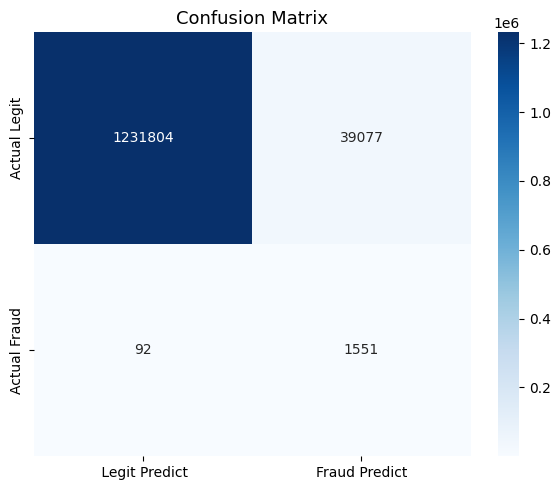

True Negatives (correctly flagged Legit): 1231804
False Positives (legit flagged as Fraud): 39077
False Negative (Missed Fraud): 92
True Positives(correctly flagged as Fraud): 1551


In [34]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[' Legit Predict', 'Fraud Predict'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title('Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp= cm.ravel()
print(f'True Negatives (correctly flagged Legit): {tn}')
print(f'False Positives (legit flagged as Fraud): {fp}')
print(f'False Negative (Missed Fraud): {fn}')
print(f'True Positives(correctly flagged as Fraud): {tp}')

**Interpretation**:

The confusion matrix shows that the model correctly classified 1231804legitimate and 1631 fraudulent transactions. Only 92 fraudulent transaction were missed, demonstrating the model's strong ability to detect fraud. 39077 legitimate transactions were incorrectly flagged as fraudulent. While this increases the number of false alarms, the model still identify the majority of fraudulent transactions which is important than minimizing false alarms in fraud detection systems where identifying fraudulent activity is a priority.

## ROC and Precision Recall Curves

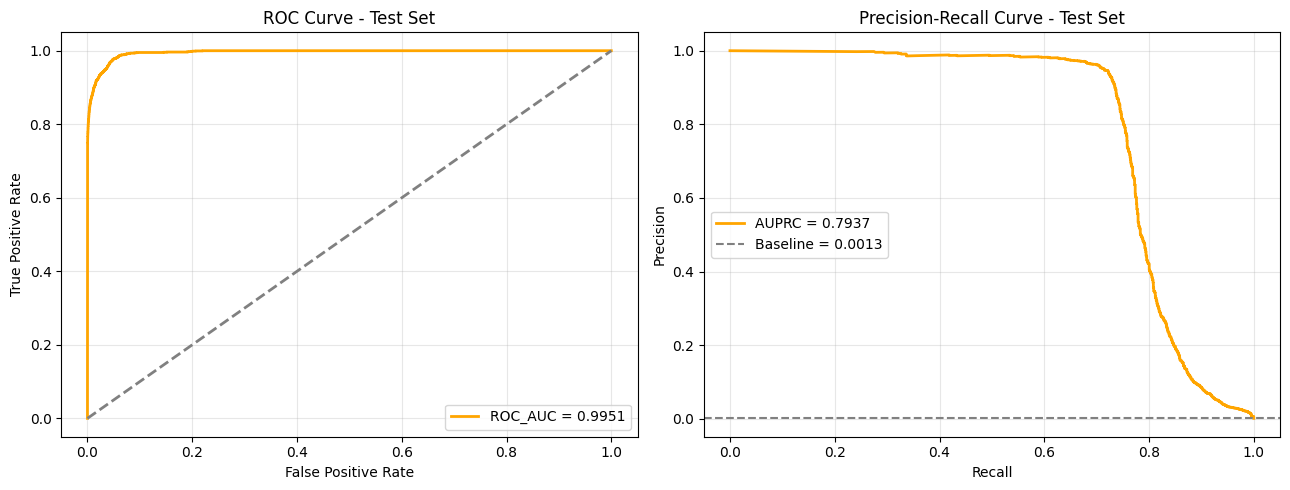

In [26]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC Curve
fpr, tpr, _=roc_curve(y_test, y_test_prob)
roc = roc_auc_score(y_test, y_test_prob)
axes[0].plot(fpr, tpr, color='orange', lw=2, label=f'ROC_AUC = {roc:.4f}')
axes[0].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Test Set', fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_prob)
pr = average_precision_score(y_test, y_test_prob)
axes[1].plot(recall, precision, color='orange', lw=2, label=f'AUPRC = {pr:.4f}')
baseline = y_test.mean()
axes[1].axhline(baseline, linestyle='--', color='gray', label=f'Baseline = {baseline:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve - Test Set', fontsize=12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation**:

- The ROC curve rises sharply towards the upper left corner and remains close to the top edge of the graph. this indicates that the model achieves a high true positive rate while maintaning a very low false positive rate across different classification thresholds. The curve lies above the diagonal reference line, demonstrating that the model performs significantly better than random guessing. The ROC AUC score of 0.9951 confirms the model's excellent ability to differentiate fraudulent transactions from legitimate transactions.
- The precision- Recall curve remains close to the upper boundary for most recall values indicating that the model maintains high precision while successfully identifying fraudulent transactions. Precision only starts to decline as recall approaches its maximum value demonstrating the expected trade off between detecting more fraud cases and generating additional false positive.

## Threshold Analysis

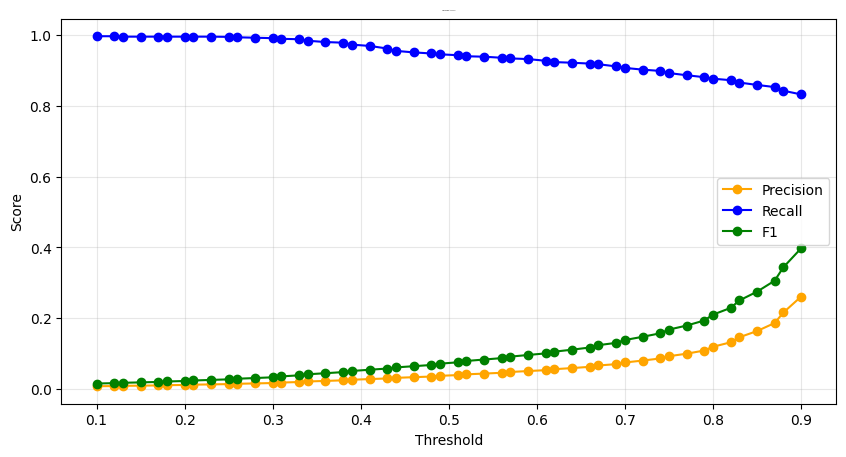

Best threshold: 0.9000, F1: 0.3971
Precision: 0.2608, Recall: 0.8320


In [27]:
thresholds = np.linspace(0.1, 0.9, num=50)
threshold_results = []

for t in thresholds:
    y_test_pred = (y_test_prob >= t).astype(int)
    threshold_results.append({
      'threshold': round(t, 2),
      'precision': precision_score(y_test, y_test_pred, zero_division=0),
      'recall': recall_score(y_test, y_test_pred),
      'f1': f1_score(y_test, y_test_pred)})

thr_df = pd.DataFrame(threshold_results)

plt.figure(figsize=(10, 5))
plt.plot(thr_df['threshold'], thr_df['precision'], label='Precision', marker='o', color='orange')
plt.plot(thr_df['threshold'], thr_df['recall'], label='Recall', marker='o', color='blue')
plt.plot(thr_df['threshold'], thr_df['f1'], label='F1', marker='o', color='green')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Threshold Analysis', fontsize=1)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_threshold = thr_df.loc[thr_df['f1'].idxmax()]
print(f'Best threshold: {best_threshold['threshold']:.4f}, F1: {best_threshold['f1']:.4f}')
print(f'Precision: {best_threshold['precision']:.4f}, Recall: {best_threshold['recall']:.4f}')

**Interpretation**: The threshold analysis demonstrates the trade off between precision and recall. As the classification threshold increases, precision improves while recall gradually decreases. The highest F1 score of 0.3971 was achieved at a threshold of 0.90 with precision increasing to 26.08% and recall remaining high at 83.20%. This suggests that a higher threshold may provide a better balance between fraud detection and false alarm reduction than the default threshold of 0.50.

## Feature Importance

In [28]:
FEATURES = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest', 'isTransferOrCashOut',
            'orig_balance_diff', 'dest_balance_diff', 'orig_zero_balance',
            'dest_zero_balance', 'type_CASH_IN', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


Top 5 Features by Importance:


'            feature  importance\n  orig_balance_diff    0.695245\n  dest_zero_balance    0.309185\nisTransferOrCashOut    0.074099\n      type_TRANSFER    0.057610\n               step    0.055143'

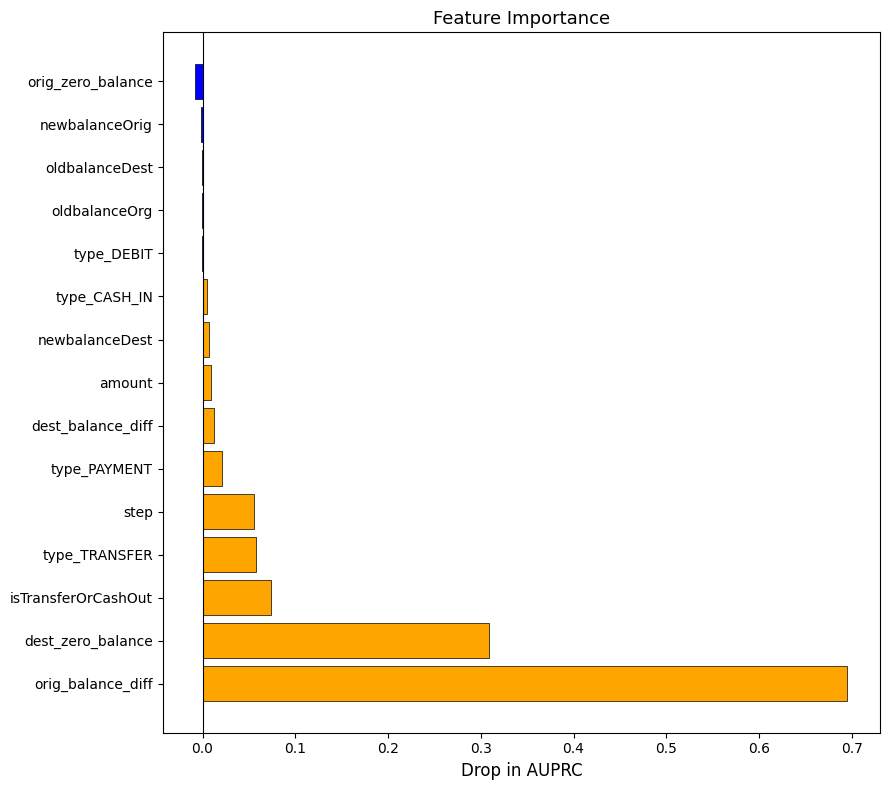

In [29]:
from math import perm
np.random.seed(42)
sample_idx = np.random.choice(len(x_train_sc), size=50000, replace=False)
x_sample = x_train_sc[sample_idx]
y_sample = y_train[sample_idx]

baseline_auprc = average_precision_score(y_sample,
                                         best_model.predict(x_sample, verbose=0).flatten())

importances_scores = []
for i, feat_name in enumerate(FEATURES):
    x_permuted = x_sample.copy()
    np.random.shuffle(x_permuted[:, i])
    permuted_auprc = average_precision_score(y_sample,
                                           best_model.predict(x_permuted, verbose=0).flatten())
    importances_scores.append({'feature': feat_name, 'importance': baseline_auprc - permuted_auprc})
imp_df = pd.DataFrame(importances_scores).sort_values(by='importance', ascending=False)

plt.figure(figsize=(9, 8))
colors = ['orange' if v > 0 else 'blue' for v in imp_df['importance']]
plt.barh(imp_df['feature'], imp_df['importance'], color=colors, edgecolor='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Drop in AUPRC', fontsize=12)
plt.title('Feature Importance', fontsize=13)
plt.tight_layout()
plt.show

print('\nTop 5 Features by Importance:')
imp_df.sort_values(by='importance', ascending=False).head(5).to_string(index=False)


**Interpretation**:

- This analysis indicates that balanced related variables have significant influence on fraud detection. The most important feature was dest_zero_balance followed by orig_balance_diff.  Transaction type related features such as type_TRANSFER and isTransferorCASHOut also contributed to model prediction. This suggests that unusual account balance movements and trasfer related transaction patterns are the most influential indicators of fraudulent activity within the dataset.

# Conclusion

- The objective of this project was to develop a deep learning model capable of detecting fraudulent financial transactions. Explotatory Data Analysis showed that the dataset was highly imbalanced with fraudelent transactions representing only a small portion of the total observations. The analysis also showed that fraud occured primarily in TRANSFER and CASH_OUT transactions and that fraudulent transactions generally involved larger transaction amounts than legitimate transactions. In addition balance related variables appreared to play an important role in distinguishing fraudulent activity from normal transaction behaviour.

- To improve the model's ability to identify fraud several new features were engineered from the original transaction data. These included balance error measures, balance difference, transaction type indicators and zero balance flags. After encoding categorial variables and selecting the final set of features, multiple neural network configurations were evaluated to determine the most effective architecture. The selected model consisted of four hidden layers and incorporated techiniques such as Batch Normalization, Dropout and L2 regularization to improve generalisation and reduce overfitting.

- The final model achieved strong performance on unseen test dataset with a ROC AUC score of 0.9951, an Average Precision score of 0.7973 and a Recall score of 0.9440. These results indicate that the model was able to correctly identify the majority of fraudulent transactions while mantaining excellent overall classification performance. Further analysis through the confusion matrix ROC curve, Precision Recall curve, Threshold analysis and feature importance assessment confirmed that the model learned meaningful transaction patterns and relied heavily on balance related information when detecting fraud.

- The findings demonstrated that deep learning can be effectively applied to large scale financial transaction data for fraud detection. The developed model provides a reliable approach for identifying suspicious transactions and could assist financial institutions in reducing fraud related losses while improving transaction monitoring processes.

## Limitations and Recommendations

Although the model achieved excellent performance several limitations should be considered:

- The PaySim dataset is a simulated dataset and may not fully capture the complexity of the real world financial transactions. As a result, model performance may differ when applied to the real financial industry environment.

- The model was trained using transaction level feature only and does not incorporate customer behavioural patterns or transaction history. Features such as transaction frequency, spending habits and account activity over time could potentially improve fraud detection performance.

- The threshold analysis also demostrate that model performance is sensitive to the classification threshold. Therefore, the threshold should be adjusted according to business requirements and the relative costs of false positives and false negatives.

- Future work could explore more advanced architectures including recurrent neural networks, LSTMs or Transformer based models capable of capturing sequential transaction behaviour.

# References

ResearchGate. (n.d.). (PDF) PAYSIM: A FINANCIAL MOBILE MONEY SIMULATOR FOR FRAUD DETECTION. [online] Available at: https://www.researchgate.net/publication/313138956_PAYSIM_A_FINANCIAL_MOBILE_MONEY_SIMULATOR_FOR_FRAUD_DETECTION.

‌TensorFlow. (2023). Keras: The high-level API for TensorFlow. [online] Available at: https://www.tensorflow.org/guide/keras?utm [Accessed 18 Jun. 2026].

‌Team, K. (2019). Keras documentation: The Functional API. [online] Keras.io. Available at: https://keras.io/guides/functional_api/?utm [Accessed 18 Jun. 2026].

‌Team, K. (2026). Keras documentation: BatchNormalization layer. [online] Keras.io. Available at: https://keras.io/api/layers/normalization_layers/batch_normalization/?utm [Accessed 18 Jun. 2026].

‌Team, K. (2026). Keras documentation: Dropout layer. [online] Keras.io. Available at: https://keras.io/api/layers/regularization_layers/dropout/?utm [Accessed 18 Jun. 2026].

‌Imbalanced-learn.org. (2026). User guide: contents — Version 0.14.2. [online] Available at: https://imbalanced-learn.org/stable/user_guide.html?utm [Accessed 18 Jun. 2026].

‌Brownlee, J. (2018). How to Use ROC Curves and Precision-Recall Curves for Classification in Python - MachineLearningMastery.com. [online] MachineLearningMastery.com. Available at: https://machinelearningmastery.com/roc-curves-and-precision-recall-curves-for-classification-in-python/?utm [Accessed 18 Jun. 2026].

‌scikit-learn. (2026). 5.2. Permutation feature importance. [online] Available at: https://scikit-learn.org/stable/modules/permutation_importance.html?utm [Accessed 18 Jun. 2026].

‌on, C. (2024). Classification on imbalanced data. [online] TensorFlow. Available at: https://www.tensorflow.org/tutorials/structured_data/imbalanced_data?utm_source#download_the_kaggle_credit_card_fraud_data_set [Accessed 16 Jun. 2026].

‌

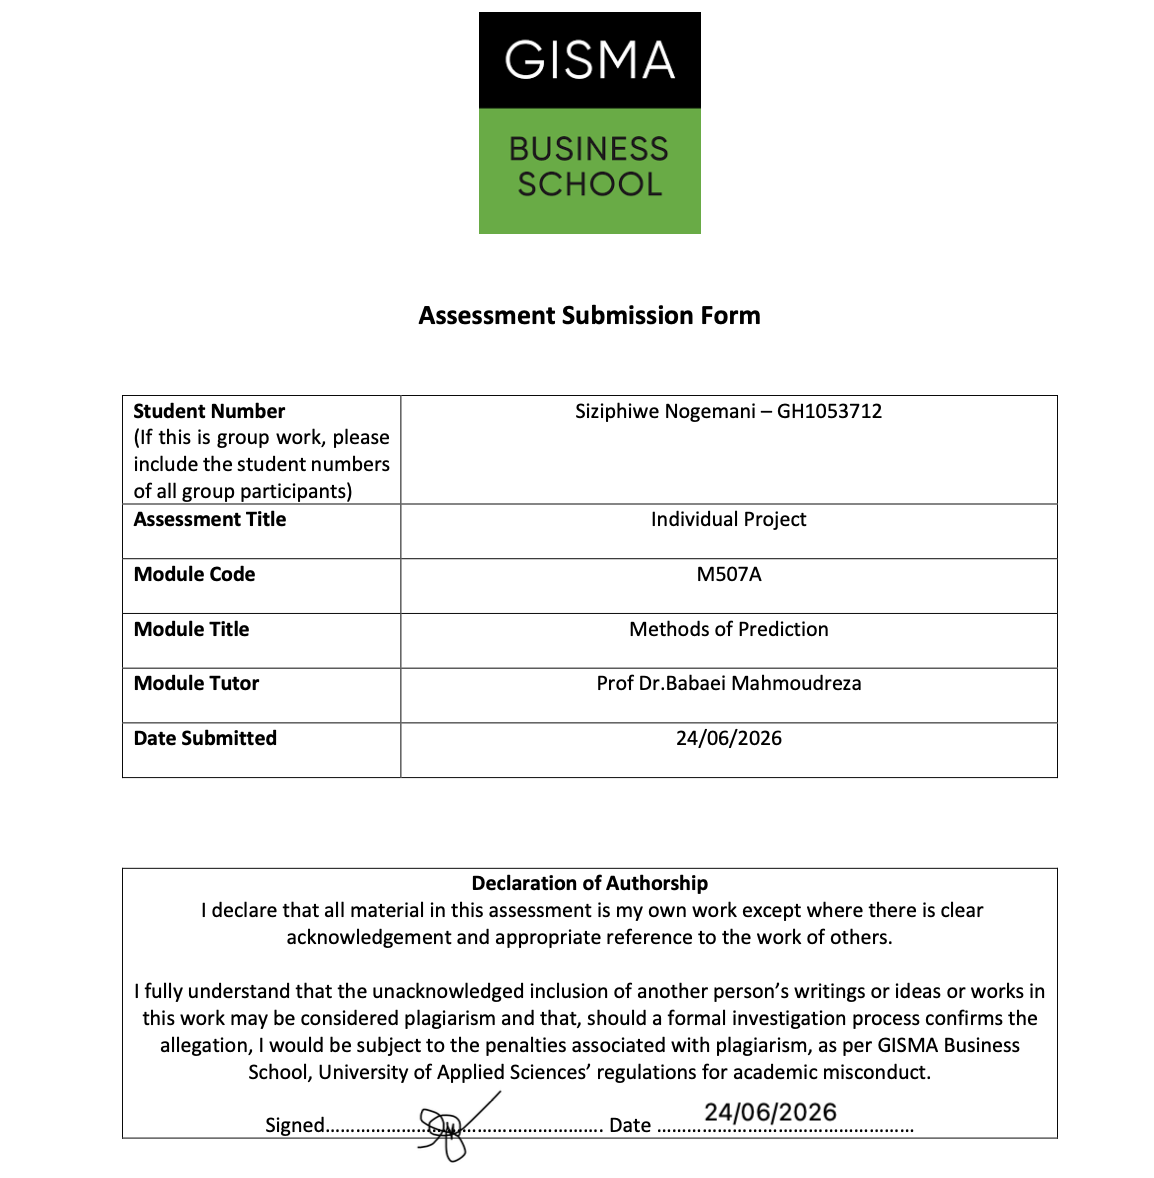